In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML
display(HTML("<style>.container { width:98% !important; }</style>"))
from pathlib import Path
from collections import Counter
import sys 
sys.path.append('/Users/johnmarshall/Documents/Analysis/JJMezTrackAnalysis')
import gcamp_peak_utils as gp
import imageio.v2 as imageio

In [3]:
salaeCSVfile = '/Users/johnmarshall/Documents/Analysis/miniscope_analysis/miniscope_T_maze/m328/raw_328.csv'
salaeData = pd.read_csv(salaeCSVfile)
timestampfileSession1 = pd.read_table('/Users/johnmarshall/Documents/Analysis/miniscope_analysis/miniscope_T_maze/m328/timeStampsMiniscope_16_44_25.csv', delimiter=',')
timestampfileSession2 = pd.read_table('/Users/johnmarshall/Documents/Analysis/miniscope_analysis/miniscope_T_maze/m328/timeStampsMiniscope_17_56_20.csv', delimiter=',')

In [4]:
salaeData

,Time [s],Channel 0,Channel 1,Channel 2,Channel 3,Channel 4,Channel 5,Channel 6,Channel 7,Channel 8,Channel 9,Channel 10,Channel 11,Channel 12,Channel 13,Channel 14,Channel 15
0,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
1,75.184965,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,75.219546,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
3,75.252180,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,75.285787,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
231108,8103.506708,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
231109,8103.539440,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
231110,8103.573055,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
231111,8103.607342,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [5]:
#Match miniscope imaging activity with salae activity

In [6]:
miniscope_full_runtime_file = pd.concat([timestampfileSession1, timestampfileSession2], ignore_index=True)
miniscope_full_runtime_file

,Frame Number,Time Stamp (ms),Buffer Index
0,0,-5,0
1,1,30,0
2,2,62,0
3,3,96,0
4,4,132,0
...,...,...,...
229686,110456,3714244,0
229687,110457,3714277,0
229688,110458,3714313,0
229689,110459,3714345,0


In [7]:
## find rows where channel 12 TTL is alternating 
rows_withMiniscopeTTL = salaeData.loc[
    (salaeData['Channel 12'] != salaeData['Channel 12'].shift(-1)) &
    (salaeData['Channel 12'] == salaeData['Channel 12'].shift(-2))
]
rows_withMiniscopeTTL = rows_withMiniscopeTTL[1:]
rows_withMiniscopeTTL

,Time [s],Channel 0,Channel 1,Channel 2,Channel 3,Channel 4,Channel 5,Channel 6,Channel 7,Channel 8,Channel 9,Channel 10,Channel 11,Channel 12,Channel 13,Channel 14,Channel 15
1,75.184965,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,75.219546,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
3,75.252180,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,75.285787,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
5,75.319905,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
231105,8103.405960,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
231106,8103.438692,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
231107,8103.472232,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
231108,8103.506708,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0


In [8]:
## get delta time in ms between salae samples 
rows_withMiniscopeTTL['Time Delta [ms]'] = abs(rows_withMiniscopeTTL['Time [s]'] - rows_withMiniscopeTTL['Time [s]'].shift(-1))
rows_withMiniscopeTTL['Time Delta [ms]'] = rows_withMiniscopeTTL['Time Delta [ms]']*1000

In [9]:
rows_withMiniscopeTTL

,Time [s],Channel 0,Channel 1,Channel 2,Channel 3,Channel 4,Channel 5,Channel 6,Channel 7,Channel 8,Channel 9,Channel 10,Channel 11,Channel 12,Channel 13,Channel 14,Channel 15,Time Delta [ms]
1,75.184965,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,34.581
2,75.219546,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,32.634
3,75.252180,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,33.607
4,75.285787,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,34.118
5,75.319905,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,33.355
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
231105,8103.405960,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,32.732
231106,8103.438692,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,33.540
231107,8103.472232,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,34.476
231108,8103.506708,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,32.732


In [10]:
# need these rows where ['Time Delta [s]'] is between 30 to 40 ms this will return periods where the miniscope is actually "recording", 
# i.e. TTLs are recorded at a consistent frequency
MiniscopeRecordingPeriods = rows_withMiniscopeTTL[(rows_withMiniscopeTTL['Time Delta [ms]'] < 40 ) & (rows_withMiniscopeTTL['Time Delta [ms]'] > 30)]
MiniscopeRecordingPeriods['TTL Gap [s]'] = abs(MiniscopeRecordingPeriods['Time [s]'] - MiniscopeRecordingPeriods['Time [s]'].shift(-1))

In [11]:
# between recording periods there will be a large spike here (pause when no consistent TTL is recorded)
MiniscopeRecordingPeriods[MiniscopeRecordingPeriods['TTL Gap [s]'] > 10]

,Time [s],Channel 0,Channel 1,Channel 2,Channel 3,Channel 4,Channel 5,Channel 6,Channel 7,Channel 8,Channel 9,Channel 10,Channel 11,Channel 12,Channel 13,Channel 14,Channel 15,Time Delta [ms],TTL Gap [s]
119955,4083.331521,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,33.11,305.923485


In [12]:
# this finds that long pause 
maxGap = MiniscopeRecordingPeriods.loc[
    MiniscopeRecordingPeriods['TTL Gap [s]'] > 10,
    'TTL Gap [s]'
].idxmax()
maxGap
pos = MiniscopeRecordingPeriods.index.get_loc(maxGap)
# "pos" here is the salae sample that should match the end of the 1st miniscope recording, start of 1st recording is 1st salae sample 
# "pos" + 1 should be the first frame of the 2nd miniscope recording , end of 2nd miniscope recording should be last sample of "MiniscopeRecordingPeriods" data frame 
pos

117305

In [13]:
## now need to match up miniscope and account for sampling frequency difference 
#miniscope recording 1
salaeSamplesMiniscopeRecording_1 = MiniscopeRecordingPeriods.iloc[0:pos]
#miniscope recording 2
salaeSamplesMiniscopeRecording_2 = MiniscopeRecordingPeriods.iloc[pos+1:]

salaeSamplesMiniscopeRecording_1

,Time [s],Channel 0,Channel 1,Channel 2,Channel 3,Channel 4,Channel 5,Channel 6,Channel 7,Channel 8,Channel 9,Channel 10,Channel 11,Channel 12,Channel 13,Channel 14,Channel 15,Time Delta [ms],TTL Gap [s]
1,75.184965,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,34.581,0.034581
2,75.219546,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,32.634,0.032634
3,75.252180,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,33.607,0.033607
4,75.285787,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,34.118,0.034118
5,75.319905,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,33.355,0.033355
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119950,4083.163230,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,33.376,0.033376
119951,4083.196606,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,34.513,0.034513
119952,4083.231119,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,32.687,0.032687
119953,4083.263806,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,33.609,0.033609


In [42]:
salaeSamplesMiniscopeRecording_1 = MiniscopeRecordingPeriods.iloc[0:pos].copy()

start_time = timestampfileSession1['Time Stamp (ms)'].iloc[0]

salaeSamplesMiniscopeRecording_1['Salae Miniscope Time (ms)'] = (
    salaeSamplesMiniscopeRecording_1['Time [s]'] - salaeSamplesMiniscopeRecording_1['Time [s]'].iloc[0]
) * 1000
salaeSamplesMiniscopeRecording_1.loc[
    salaeSamplesMiniscopeRecording_1.index[0], 'Salae Miniscope Time (ms)'
] = start_time
#Adjusts Salae timing to miniscope timing

salaeSamplesMiniscopeRecording_1 = pd.concat([
    salaeSamplesMiniscopeRecording_1.reset_index(drop=True),
    timestampfileSession1[['Frame Number', 'Time Stamp (ms)']].reset_index(drop=True)
], axis=1)

In [43]:
len(timestampfileSession1)-117305

1925

In [44]:
salaeSamplesMiniscopeRecording_1[-1930:-1920]

,Time [s],Channel 0,Channel 1,Channel 2,Channel 3,Channel 4,Channel 5,Channel 6,Channel 7,Channel 8,...,Channel 11,Channel 12,Channel 13,Channel 14,Channel 15,Time Delta [ms],TTL Gap [s],Salae Miniscope Time (ms),Frame Number,Time Stamp (ms)
117300,4083.163230,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,33.376,0.033376,4007978.265,117300,3943448
117301,4083.196606,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,34.513,0.034513,4008011.641,117301,3943482
117302,4083.231119,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,32.687,0.032687,4008046.154,117302,3943516
117303,4083.263806,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,33.609,0.033609,4008078.841,117303,3943551
117304,4083.297415,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,34.106,0.034106,4008112.450,117304,3943583
117305,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,117305,3943616
117306,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,117306,3943649
117307,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,117307,3943683
117308,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,117308,3943717
117309,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,117309,3943752


In [45]:
# original approach: found miniscope frame where the 'Time Stamp (ms)' was closest preceeding value to the 'Salae Miniscope Time (ms)' value
salaeSamplesMiniscopeRecording_1['Corresponding Miniscope Frame'] = salaeSamplesMiniscopeRecording_1['Salae Miniscope Time (ms)'].apply(
    lambda x: salaeSamplesMiniscopeRecording_1.loc[salaeSamplesMiniscopeRecording_1['Time Stamp (ms)'] <= x, 'Frame Number'].max()
)


#alternative approach, find the miniscope frame where the 'Time Stamp (ms)' was closest in absolute value to the
#'Salae Miniscope Time (ms)' value , needs to have the "np.nan if pd.isna(x)" for the rows where 'Salae Miniscope Time (ms)' is NaN
salaeSamplesMiniscopeRecording_1['Corresponding Miniscope Frame'] = (
    salaeSamplesMiniscopeRecording_1['Salae Miniscope Time (ms)'].apply(
        lambda x: np.nan if pd.isna(x) else salaeSamplesMiniscopeRecording_1.loc[
            (salaeSamplesMiniscopeRecording_1['Time Stamp (ms)'] - x).abs().idxmin(),
            'Frame Number'
        ]
    )
)

In [18]:
salaeSamplesMiniscopeRecording_1Truncated = salaeSamplesMiniscopeRecording_1[salaeSamplesMiniscopeRecording_1['Corresponding Miniscope Frame'].notna()] 
salaeSamplesMiniscopeRecording_1Truncated

,Time [s],Channel 0,Channel 1,Channel 2,Channel 3,Channel 4,Channel 5,Channel 6,Channel 7,Channel 8,...,Channel 12,Channel 13,Channel 14,Channel 15,Time Delta [ms],TTL Gap [s],Salae Miniscope Time (ms),Frame Number,Time Stamp (ms),Corresponding Miniscope Frame
0,75.184965,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,34.581,0.034581,-5.000,0,-5,0.0
1,75.219546,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,32.634,0.032634,34.581,1,30,1.0
2,75.252180,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,33.607,0.033607,67.215,2,62,2.0
3,75.285787,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,34.118,0.034118,100.822,3,96,3.0
4,75.319905,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,33.355,0.033355,134.940,4,132,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117300,4083.163230,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,33.376,0.033376,4007978.265,117300,3943448,119220.0
117301,4083.196606,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,34.513,0.034513,4008011.641,117301,3943482,119221.0
117302,4083.231119,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,32.687,0.032687,4008046.154,117302,3943516,119222.0
117303,4083.263806,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,33.609,0.033609,4008078.841,117303,3943551,119223.0


In [46]:
salaeSamplesMiniscopeRecording_1
salaeSamplesMiniscopeRecording_1.to_csv('salaeSamplesMiniscopeRecording_1.csv')

In [47]:
salaeSamplesMiniscopeRecording_2 = MiniscopeRecordingPeriods.iloc[pos+1:]
salaeSamplesMiniscopeRecording_2

,Time [s],Channel 0,Channel 1,Channel 2,Channel 3,Channel 4,Channel 5,Channel 6,Channel 7,Channel 8,Channel 9,Channel 10,Channel 11,Channel 12,Channel 13,Channel 14,Channel 15,Time Delta [ms],TTL Gap [s]
120029,4389.255006,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,32.972,0.032972
120030,4389.287978,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,33.601,0.033601
120031,4389.321579,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,33.805,0.033805
120032,4389.355384,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,33.414,0.033414
120033,4389.388798,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,33.601,0.033601
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
231104,8103.371397,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,34.563,0.034563
231105,8103.405960,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,32.732,0.032732
231106,8103.438692,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,33.540,0.033540
231107,8103.472232,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,34.476,0.034476


In [48]:
start_time = timestampfileSession2['Time Stamp (ms)'].iloc[0]


salaeSamplesMiniscopeRecording_2['Salae Miniscope Time (ms)'] = (
    salaeSamplesMiniscopeRecording_2['Time [s]'] - salaeSamplesMiniscopeRecording_2['Time [s]'].iloc[0]
) * 1000
salaeSamplesMiniscopeRecording_2.loc[
    salaeSamplesMiniscopeRecording_2.index[0], 'Salae Miniscope Time (ms)'
] = start_time
#Adjusts Salae timing to miniscope timing

salaeSamplesMiniscopeRecording_2 = salaeSamplesMiniscopeRecording_2.drop(columns=['Time Stamp (ms)', 'Frame Number'], errors='ignore')

salaeSamplesMiniscopeRecording_2 = pd.concat([
    salaeSamplesMiniscopeRecording_2.reset_index(drop=True),
    timestampfileSession2[['Frame Number', 'Time Stamp (ms)']].reset_index(drop=True)
], axis=1)

In [49]:
print(len(salaeSamplesMiniscopeRecording_2))  # salae rows
print(len(timestampfileSession2))  

110461
110461


In [50]:
salaeSamplesMiniscopeRecording_2 = salaeSamplesMiniscopeRecording_2.dropna(subset=['Salae Miniscope Time (ms)'])

salaeSamplesMiniscopeRecording_2['Corresponding Miniscope Frame'] = salaeSamplesMiniscopeRecording_2['Salae Miniscope Time (ms)'].apply(
    lambda x: salaeSamplesMiniscopeRecording_2.loc[salaeSamplesMiniscopeRecording_2['Time Stamp (ms)'] <= x, 'Frame Number'].max()
)

In [51]:
salaeSamplesMiniscopeRecording_2
salaeSamplesMiniscopeRecording_2.to_csv('salaeSamplesMiniscopeRecording_2.csv')

In [56]:
salaeSamplesMiniscopeRecording_1_truncated=salaeSamplesMiniscopeRecording_1[salaeSamplesMiniscopeRecording_1['Corresponding Miniscope Frame']<115234]
salaeSamplesMiniscopeRecording_1_truncated

,Time [s],Channel 0,Channel 1,Channel 2,Channel 3,Channel 4,Channel 5,Channel 6,Channel 7,Channel 8,...,Channel 12,Channel 13,Channel 14,Channel 15,Time Delta [ms],TTL Gap [s],Salae Miniscope Time (ms),Frame Number,Time Stamp (ms),Corresponding Miniscope Frame
0,75.184965,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,34.581,0.034581,-5.000,0,-5,0.0
1,75.219546,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,32.634,0.032634,34.581,1,30,1.0
2,75.252180,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,33.607,0.033607,67.215,2,62,2.0
3,75.285787,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,34.118,0.034118,100.822,3,96,3.0
4,75.319905,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,33.355,0.033355,134.940,4,132,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113356,3949.003602,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,34.182,0.034182,3873818.637,113356,3810867,115229.0
113357,3949.037784,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,33.214,0.033214,3873852.819,113357,3810901,115230.0
113358,3949.070998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,33.438,0.033438,3873886.033,113358,3810934,115231.0
113359,3949.104436,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,33.607,0.033607,3873919.471,113359,3810967,115232.0


In [25]:
# --- Load aligned salae session 1 ---

salae_1 = pd.read_csv('salaeSamplesMiniscopeRecording_1.csv')

# --- Find Ch11 rising edges ---

ch11_rises = salae_1[
    (salae_1["Channel 11"] == 1) & (salae_1["Channel 11"].shift(1) == 0)
]["Time [s]"].values

# --- Find Ch6 falling edges (delay start) ---

ch6_falling = salae_1[
    (salae_1["Channel 6"] == 0) & (salae_1["Channel 6"].shift(1) == 1)
]["Time [s]"].values

# --- Find last Ch3 or Ch4 rising edge before each Ch6 falling edge (which arm was forced) ---

ch3_rising = salae_1[
    (salae_1["Channel 3"] == 1) & (salae_1["Channel 3"].shift(1) == 0)
][["Time [s]"]].copy()
ch3_rising["forced_side"] = "left"

ch4_rising = salae_1[
    (salae_1["Channel 4"] == 1) & (salae_1["Channel 4"].shift(1) == 0)
][["Time [s]"]].copy()
ch4_rising["forced_side"] = "right"

ch34_rising = pd.concat([ch3_rising, ch4_rising]).sort_values("Time [s]")

# --- For each Ch11 rising edge, find the preceding Ch6 falling edge ---
# and classify as a real delay period (5s or 30s only)

delay_trials = []
trial_number = 0

for t11 in ch11_rises:
    # find last Ch6 falling edge before this Ch11
    preceding_ch6 = ch6_falling[ch6_falling < t11]
    if len(preceding_ch6) == 0:
        continue

    delay_start_time = preceding_ch6[-1]
    gap = t11 - delay_start_time

    # only keep real delay periods
    if 4 < gap < 8:
        delay_type = 5
    elif 25 < gap < 35:
        delay_type = 30
    else:
        continue  # skip 0s trials

    # find last Ch3/Ch4 rising edge before the Ch6 falling edge
    preceding_ch34 = ch34_rising[ch34_rising["Time [s]"] < delay_start_time]
    if len(preceding_ch34) == 0:
        forced_side = "unknown"
    else:
        forced_side = preceding_ch34.iloc[-1]["forced_side"]

    # find closest miniscope frames
    start_idx = (salae_1["Time [s]"] - delay_start_time).abs().idxmin()
    end_idx = (salae_1["Time [s]"] - t11).abs().idxmin()

    trial_number += 1

    delay_trials.append({
        "trial_number": trial_number,
        "forced_side": forced_side,
        "delay_duration_s": round(gap, 3),
        "delay_start_time": delay_start_time,
        "delay_end_time": t11,
        "delay_start_frame": salae_1.loc[start_idx, "Corresponding Miniscope Frame"],
        "delay_end_frame": salae_1.loc[end_idx, "Corresponding Miniscope Frame"]
    })

delay_df_session1 = pd.DataFrame(delay_trials)

delay_df_session1.to_csv("delay_periods_session1.csv", index=False)

print(f"Total delay trials: {len(delay_df_session1)}")
print(f"  5s delays:  {len(delay_df_session1[delay_df_session1.delay_duration_s < 10])}")
print(f"  30s delays: {len(delay_df_session1[delay_df_session1.delay_duration_s > 10])}")
print(f"  Left forced:  {len(delay_df_session1[delay_df_session1.forced_side == 'left'])}")
print(f"  Right forced: {len(delay_df_session1[delay_df_session1.forced_side == 'right'])}")

display(delay_df_session1)

Total delay trials: 12
  5s delays:  6
  30s delays: 6
  Left forced:  6
  Right forced: 6


,trial_number,forced_side,delay_duration_s,delay_start_time,delay_end_time,delay_start_frame,delay_end_frame
0,1,right,4.939,257.067236,262.006716,5412.0,5559.0
1,2,left,30.081,456.053984,486.135164,11333.0,12228.0
2,3,left,5.040,688.783964,693.824014,18258.0,18408.0
3,4,right,30.078,914.421351,944.499123,24965.0,25860.0
4,5,right,29.944,1437.514767,1467.458657,40526.0,41416.0
5,6,left,5.040,1834.112381,1839.152712,52325.0,52475.0
6,7,right,5.512,2216.492839,2222.004723,63703.0,63867.0
7,8,left,30.179,2432.284365,2462.463806,70124.0,71022.0
8,9,left,5.511,2819.269724,2824.780927,81623.0,81787.0
9,10,left,30.579,3197.520441,3228.098971,92877.0,93780.0


In [27]:
# --- Load aligned salae session 2 ---

salae_2 = pd.read_csv('salaeSamplesMiniscopeRecording_2.csv')

# --- Find Ch11 rising edges ---

ch11_rises = salae_2[
    (salae_2["Channel 11"] == 1) & (salae_2["Channel 11"].shift(1) == 0)
]["Time [s]"].values

# --- Find Ch6 falling edges (delay start) ---

ch6_falling = salae_2[
    (salae_2["Channel 6"] == 0) & (salae_2["Channel 6"].shift(1) == 1)
]["Time [s]"].values

# --- Find last Ch3 or Ch4 rising edge before each Ch6 falling edge ---

ch3_rising = salae_2[
    (salae_2["Channel 3"] == 1) & (salae_2["Channel 3"].shift(1) == 0)
][["Time [s]"]].copy()
ch3_rising["forced_side"] = "left"

ch4_rising = salae_2[
    (salae_2["Channel 4"] == 1) & (salae_2["Channel 4"].shift(1) == 0)
][["Time [s]"]].copy()
ch4_rising["forced_side"] = "right"

ch34_rising = pd.concat([ch3_rising, ch4_rising]).sort_values("Time [s]")

# --- For each Ch11 rising edge, find the preceding Ch6 falling edge ---

delay_trials = []
trial_number = 0

for t11 in ch11_rises:
    preceding_ch6 = ch6_falling[ch6_falling < t11]
    if len(preceding_ch6) == 0:
        continue

    delay_start_time = preceding_ch6[-1]
    gap = t11 - delay_start_time

    if 4 < gap < 8:
        delay_type = 5
    elif 25 < gap < 35:
        delay_type = 30
    else:
        continue

    preceding_ch34 = ch34_rising[ch34_rising["Time [s]"] < delay_start_time]
    if len(preceding_ch34) == 0:
        forced_side = "unknown"
    else:
        forced_side = preceding_ch34.iloc[-1]["forced_side"]

    start_idx = (salae_2["Time [s]"] - delay_start_time).abs().idxmin()
    end_idx = (salae_2["Time [s]"] - t11).abs().idxmin()

    trial_number += 1

    delay_trials.append({
        "trial_number": trial_number,
        "forced_side": forced_side,
        "delay_duration_s": round(gap, 3),
        "delay_start_time": delay_start_time,
        "delay_end_time": t11,
        "delay_start_frame": salae_2.loc[start_idx, "Corresponding Miniscope Frame"],
        "delay_end_frame": salae_2.loc[end_idx, "Corresponding Miniscope Frame"]
    })

delay_df_session2 = pd.DataFrame(delay_trials)

delay_df_session2.to_csv("delay_periods_session2.csv", index=False)

print(f"Total delay trials: {len(delay_df_session2)}")
print(f"  5s delays:  {len(delay_df_session2[delay_df_session2.delay_duration_s < 10])}")
print(f"  30s delays: {len(delay_df_session2[delay_df_session2.delay_duration_s > 10])}")
print(f"  Left forced:  {len(delay_df_session2[delay_df_session2.forced_side == 'left'])}")
print(f"  Right forced: {len(delay_df_session2[delay_df_session2.forced_side == 'right'])}")

display(delay_df_session2)

Total delay trials: 11
  5s delays:  6
  30s delays: 5
  Left forced:  5
  Right forced: 6


,trial_number,forced_side,delay_duration_s,delay_start_time,delay_end_time,delay_start_frame,delay_end_frame
0,1,right,5.175,5190.883394,5196.058886,23844,23998
1,2,right,30.145,5311.197628,5341.342166,27424,28321
2,3,left,5.576,5457.423866,5462.999699,31775,31941
3,4,right,5.949,5702.181072,5708.129690,39058,39235
4,5,right,30.513,5857.313771,5887.827213,43665,44573
5,6,left,5.343,6171.537747,6176.880679,53012,53171
6,7,left,30.550,6510.161830,6540.711520,63088,63997
7,8,right,30.145,7153.704192,7183.849626,82202,83099
8,9,right,5.578,7512.327423,7517.904941,92873,93039
9,10,left,30.012,7861.569125,7891.580924,103265,104158


In [29]:
## load calcium traces 
calciumData = pd.read_table('/Users/johnmarshall/Documents/Analysis/miniscope_analysis/miniscope_T_maze/m328/LF_analysis/328_C_traces_filtered_origHz.csv', delimiter=',')

In [37]:
calciumData

,Unnamed: 0,cell_1,cell_2,cell_4,cell_5,cell_8,cell_9,cell_10,cell_11,cell_12,...,cell_299,cell_300,cell_302,cell_303,cell_304,cell_305,cell_306,cell_307,cell_308,cell_309
0,0 days 00:00:00,-0.605606,7.869244,-0.499119,-0.595185,-0.342970,-0.549936,-0.572430,3.416981,-0.633596,...,-0.485753,-0.642576,0.610223,3.361113,1.005590,1.168537,0.691617,-0.434580,-0.647135,1.614950
1,0 days 00:00:00.050000,-0.605606,1.124798,0.222773,-0.595185,-0.153463,-0.549936,-0.572430,1.045004,-0.633596,...,-0.485753,2.017369,-0.697508,2.048084,-0.660291,-0.692100,11.914185,-0.499190,-0.647135,-0.664706
2,0 days 00:00:00.100000,-0.605606,2.954716,2.732061,0.330279,-0.342970,-0.549936,-0.572430,2.344835,-0.633596,...,-0.485753,1.782693,-0.593100,0.438445,12.444121,-0.692100,-0.274542,-0.383015,-0.647135,-0.436779
3,0 days 00:00:00.150000,-0.605606,1.204970,1.029710,-0.547890,-0.342970,-0.549936,-0.572430,-0.423562,1.135043,...,-0.485753,-0.642576,0.288491,-0.248011,1.304544,-0.692100,-0.632893,-0.591934,-0.647135,0.681317
4,0 days 00:00:00.200000,-0.605606,-0.534428,-0.655705,-0.160419,-0.342970,-0.549936,-0.158138,0.088094,-0.633596,...,-0.485753,-0.642576,-0.697508,-0.654395,-0.679802,-0.692100,-0.632893,-0.043017,0.159067,-0.125261
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115229,0 days 01:36:01.450000,1.571383,-0.340058,0.455599,-0.595185,-0.091074,-0.549936,0.285368,-0.510275,1.347199,...,0.304031,-0.642576,0.980106,-0.654395,-0.026120,0.732135,-0.387334,-0.591934,-0.647135,-0.664706
115230,0 days 01:36:01.500000,0.339203,0.357402,0.508813,0.213098,0.041844,-0.549936,-0.572430,-0.534254,-0.633596,...,-0.485753,0.078786,0.950376,0.721136,0.187030,-0.623183,-0.632893,1.214719,-0.647135,0.145100
115231,0 days 01:36:01.550000,-0.605606,-0.534428,-0.655705,-0.595185,-0.342970,-0.549936,-0.035254,0.489156,1.387969,...,0.587985,-0.642576,0.442585,-0.654395,-0.679802,-0.610731,-0.632893,1.453986,-0.647135,-0.664706
115232,0 days 01:36:01.600000,-0.424812,0.123940,-0.655705,-0.529656,0.460344,0.522914,0.400651,-0.534254,-0.633596,...,-0.016655,-0.642576,0.593043,-0.654395,-0.679802,-0.537649,-0.081534,0.555559,-0.647135,1.742963


In [119]:
## functions for visualization
def load_calcium_traces(csv_path):
    csv_path = Path(csv_path)
    traces_df = pd.read_csv(csv_path)

    # The first column in your file is time-like; keep it if present.
    first_col = traces_df.columns[0]
    if str(first_col).startswith("Unnamed:"):
        traces_df = traces_df.rename(columns={first_col: "time"})
        try:
            traces_df["time"] = pd.to_timedelta(traces_df["time"])
        except Exception:
            pass

    return traces_df


def extract_delay_trace(traces_df, delay_periods_df, cell, trial_number=None, delay_row=None):
    """
    Extract one cell's calcium trace during one delay period.

    Parameters
    ----------
    traces_df : pd.DataFrame
        Calcium dataframe loaded from 328_C_traces_filtered_origHz.csv
    delay_periods_df : pd.DataFrame
        Dataframe with delay_start_frame / delay_end_frame
    cell : str or int
        Example: 'cell_28' or 28
    trial_number : int, optional
        Trial number from the delay dataframe
    delay_row : int, optional
        Row index in delay_periods_df (use this if not selecting by trial_number)

    Returns
    -------
    pd.DataFrame
        Slice with frame index, optional time, and the selected cell trace
    """
    if isinstance(cell, int):
        cell = f"cell_{cell}"

    if trial_number is not None:
        row = delay_periods_df.loc[delay_periods_df["trial_number"] == trial_number]
        if row.empty:
            raise ValueError(f"No row found for trial_number={trial_number}")
        if len(row) > 1:
            raise ValueError(f"Multiple rows found for trial_number={trial_number}")
        row = row.iloc[0]
    elif delay_row is not None:
        row = delay_periods_df.iloc[delay_row]
    else:
        raise ValueError("Provide either trial_number or delay_row")

    if cell not in traces_df.columns:
        raise ValueError(f"{cell} not found in traces_df")

    start_frame = int(row["delay_start_frame"])
    end_frame = int(row["delay_end_frame"])

    # end_frame is treated as inclusive
    out = traces_df.iloc[start_frame:end_frame + 1].copy()
    out["frame"] = range(start_frame, end_frame + 1)

    keep_cols = ["frame", cell]
    if "time" in out.columns:
        keep_cols.insert(1, "time")

    return out[keep_cols]


def plot_cell_during_delay(traces_df, delay_periods_df, cell, trial_number=None, delay_row=None):
    delay_trace_df = extract_delay_trace(
        traces_df=traces_df,
        delay_periods_df=delay_periods_df,
        cell=cell,
        trial_number=trial_number,
        delay_row=delay_row,
    )

    cell_name = f"cell_{cell}" if isinstance(cell, int) else cell

    fig, ax = plt.subplots(figsize=(8, 3.5))

    ax.plot(delay_trace_df["frame"], delay_trace_df[cell_name], linewidth=1.5)
    ax.set_xlabel("Miniscope frame")
    ax.set_ylabel("Calcium signal")
    ax.set_title(
        f"{cell_name} during delay "
        f"(trial {trial_number if trial_number is not None else delay_periods_df.iloc[delay_row]['trial_number']})"
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()

    return delay_trace_df

def cells_active_in_delay(
    calciumData,
    delay_periods_df,
    delay_row,
    threshold=2.5,
    min_consecutive_frames=1,
    cell_prefix="cell_",
):
    start_frame = int(delay_periods_df.iloc[delay_row]["delay_start_frame"])
    end_frame = int(delay_periods_df.iloc[delay_row]["delay_end_frame"])

    delay_slice = calciumData.iloc[start_frame:end_frame + 1]
    cell_cols = [c for c in delay_slice.columns if str(c).startswith(cell_prefix)]

    active_cells = []
    for cell in cell_cols:
        vals = pd.to_numeric(delay_slice[cell], errors="coerce").to_numpy()
        above = vals > threshold

        if min_consecutive_frames <= 1:
            is_active = np.any(above)
        else:
            is_active = np.any(
                np.convolve(above.astype(int), np.ones(min_consecutive_frames, dtype=int), mode="valid")
                >= min_consecutive_frames
            )

        if is_active:
            active_cells.append(cell)

    return active_cells

def plot_input_cell_active_delays_stacked(
    cell,
    calciumData,
    delay_periods_df,
    active_cells_summary_df,
    figsize_per_row=1.8,
    color="black",
    sharex=False,
):
    if isinstance(cell, int):
        cell = f"cell_{cell}"

    active_trials = active_cells_summary_df.loc[
        active_cells_summary_df["active_cells"].apply(lambda cells: cell in cells),
        "trial_number"
    ].tolist()

    plot_df = delay_periods_df.loc[
        delay_periods_df["trial_number"].isin(active_trials)
    ].copy()

    if plot_df.empty:
        print(f"{cell} is not active in any of the selected delay periods.")
        return

    n = len(plot_df)
    fig, axes = plt.subplots(
        n, 1,
        figsize=(10, figsize_per_row * n),
        sharex=sharex
    )

    if n == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, plot_df.iterrows()):
        start_frame = int(row["delay_start_frame"])
        end_frame = int(row["delay_end_frame"])

        y = pd.to_numeric(
            calciumData[cell].iloc[start_frame:end_frame + 1],
            errors="coerce"
        ).to_numpy()

        x = np.arange(start_frame, end_frame + 1)

        ax.plot(x, y, color=color, linewidth=1.4)
        ax.set_ylabel(cell)
        ax.set_title(
            f"Trial {int(row['trial_number'])} | "
            f"{row['forced_side']} | "
            f"{row['delay_duration_s']:.2f} s"
        )
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[-1].set_xlabel("Miniscope frame")
    fig.suptitle(f"{cell}: activity during selected delay periods with events", y=1.02)

    plt.tight_layout()
    plt.show()

def correlate_input_cell_across_delays(
    cell,
    calciumData,
    delay_periods_df,
    threshold=2.5,
    bin_width_frames=5,
    active_cells_summary_df=None,
    only_active_delays=True,
    binarize_mode="any",   # "any" or "mean"
):
    if isinstance(cell, int):
        cell = f"cell_{cell}"

    work_df = delay_periods_df.copy()

    if active_cells_summary_df is not None and only_active_delays:
        active_trials = active_cells_summary_df.loc[
            active_cells_summary_df["active_cells"].apply(lambda cells: cell in cells),
            "trial_number"
        ].tolist()
        work_df = work_df.loc[work_df["trial_number"].isin(active_trials)].copy()

    if work_df.empty:
        print(f"No matching delay periods found for {cell}.")
        return None, None, None

    binarized_traces = []
    labels = []
    meta_rows = []

    for _, row in work_df.iterrows():
        start_frame = int(row["delay_start_frame"])
        end_frame = int(row["delay_end_frame"])

        y = pd.to_numeric(
            calciumData[cell].iloc[start_frame:end_frame + 1],
            errors="coerce"
        ).to_numpy()

        n_full_bins = len(y) // bin_width_frames
        if n_full_bins < 1:
            continue

        y = y[:n_full_bins * bin_width_frames].reshape(n_full_bins, bin_width_frames)

        if binarize_mode == "any":
            b = (np.nanmax(y, axis=1) > threshold).astype(int)
        elif binarize_mode == "mean":
            b = (np.nanmean(y, axis=1) > threshold).astype(int)
        else:
            raise ValueError("binarize_mode must be 'any' or 'mean'")

        binarized_traces.append(b)
        labels.append(f"T{int(row['trial_number'])}")
        meta_rows.append({
            "trial_number": int(row["trial_number"]),
            "forced_side": row["forced_side"],
            "delay_duration_s": row["delay_duration_s"],
            "n_bins": len(b),
        })

    if len(binarized_traces) < 2:
        print(f"Need at least 2 delay periods to compute correlations for {cell}.")
        return None, None, pd.DataFrame(meta_rows)

    min_len = min(len(x) for x in binarized_traces)
    X = np.vstack([x[:min_len] for x in binarized_traces])

    corr = np.full((X.shape[0], X.shape[0]), np.nan, dtype=float)
    for i in range(X.shape[0]):
        for j in range(X.shape[0]):
            xi = X[i]
            xj = X[j]
            if np.std(xi) == 0 or np.std(xj) == 0:
                corr[i, j] = 1.0 if i == j else np.nan
            else:
                corr[i, j] = np.corrcoef(xi, xj)[0, 1]

    corr_df = pd.DataFrame(corr, index=labels, columns=labels)
    binned_df = pd.DataFrame(X, index=labels, columns=[f"bin_{i}" for i in range(min_len)])
    meta_df = pd.DataFrame(meta_rows, index=labels)

    return corr_df, binned_df, meta_df



In [132]:
# list cells active during defined delay periods
active_cells_summary = []
for delay_row in range(len(delay_df_session1)):
    active_cells = cells_active_in_delay(
        calciumData=calciumData,
        delay_periods_df=delay_df_session1,
        delay_row=delay_row,
        threshold=2.5,
        min_consecutive_frames=2,
    )
    active_cells_summary.append({
        "delay_row": delay_row,
        "trial_number": delay_df_session1.iloc[delay_row]["trial_number"],
        "forced_side": delay_df_session1.iloc[delay_row]["forced_side"],
        "delay_duration_s": delay_df_session1.iloc[delay_row]["delay_duration_s"],
        "n_active_cells": len(active_cells),
        "active_cells": active_cells,
    })
active_cells_summary_df = pd.DataFrame(active_cells_summary)
active_cells_summary_df

,delay_row,trial_number,forced_side,delay_duration_s,n_active_cells,active_cells
0,0,1,right,4.939,68,"[cell_2, cell_13, cell_14, cell_19, cell_23, c..."
1,1,2,left,30.081,161,"[cell_2, cell_4, cell_5, cell_10, cell_11, cel..."
2,2,3,left,5.040,55,"[cell_5, cell_11, cell_26, cell_34, cell_43, c..."
3,3,4,right,30.078,157,"[cell_1, cell_4, cell_9, cell_11, cell_12, cel..."
4,4,5,right,29.944,142,"[cell_1, cell_2, cell_9, cell_10, cell_13, cel..."
5,5,6,left,5.040,52,"[cell_1, cell_2, cell_12, cell_22, cell_25, ce..."
6,6,7,right,5.512,40,"[cell_5, cell_18, cell_29, cell_32, cell_33, c..."
7,7,8,left,30.179,157,"[cell_1, cell_2, cell_4, cell_5, cell_8, cell_..."
8,8,9,left,5.511,44,"[cell_1, cell_2, cell_4, cell_12, cell_20, cel..."
9,9,10,left,30.579,164,"[cell_1, cell_2, cell_4, cell_5, cell_9, cell_..."


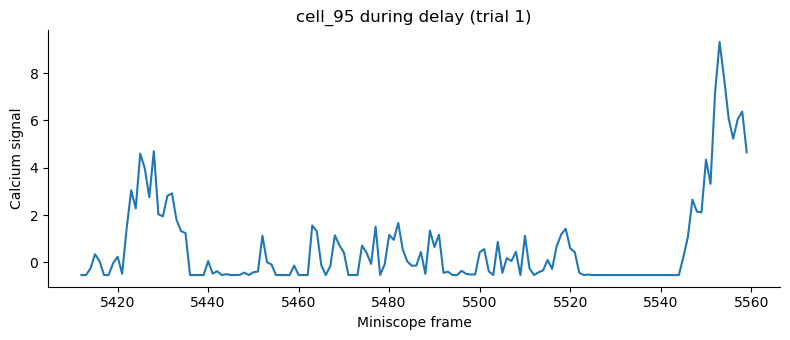

In [149]:
#single cell trace during single delay period 
delay_trace_df = plot_cell_during_delay(
    traces_df=calciumData,
    delay_periods_df=delay_df_session1,
    cell="cell_95",
    trial_number=1,
)


In [148]:
#cell video activity during delay period 
pathToEXTRACT = '/Users/johnmarshall/Documents/Analysis/miniscope_analysis/miniscope_T_maze/m328/part1/_denoised_converted_concat_ds_mc_det_20260523_213313_474.mat'

delay_row = 0
cell_name = "cell_95"

row = delay_df_session1.iloc[delay_row]
start_frame = int(row["delay_start_frame"])
end_frame = int(row["delay_end_frame"])

center_idx = (start_frame + end_frame) // 2
before = center_idx - start_frame
after = end_frame - center_idx + 1   # +1 so end_frame is included

save_dir = Path("/Users/johnmarshall/Documents/Analysis/miniscope_analysis/miniscope_T_maze/m328/part1/")
save_path = save_dir / f"{cell_name}_delay_trial_{int(row['trial_number']):02d}.mp4"

movie_uint8, meta = gp.build_single_cell_peak_movie(
    pathToEXTRACT,
    cell_name,
    center_idx,
    window=(before, after),
    stats_df=None,
    include_all_cells=True,
    highlight_cell=True,
    highlight_strength=1.0,
)

imageio.mimsave(
    save_path,
    movie_uint8,
    fps=20,
    macro_block_size=1,
)

print(save_path)



/Users/johnmarshall/Documents/Analysis/miniscope_analysis/miniscope_T_maze/m328/part1/cell_95_delay_trial_01.mp4


In [133]:
# cells active in all delay periods 
cellsActiveInAllDataFrames=sorted(set.intersection(*map(set, active_cells_summary_df["active_cells"])))
print(cellsActiveInAllDataFrames) 
# cells most active across delay periods
cell_counts = Counter(cell for cells in active_cells_summary_df["active_cells"] for cell in cells)
sorted_cells = cell_counts.most_common()
print(sorted_cells)

[]
[('cell_95', 10), ('cell_101', 9), ('cell_104', 9), ('cell_221', 9), ('cell_236', 9), ('cell_237', 9), ('cell_241', 9), ('cell_282', 9), ('cell_2', 8), ('cell_86', 8), ('cell_89', 8), ('cell_92', 8), ('cell_131', 8), ('cell_141', 8), ('cell_156', 8), ('cell_170', 8), ('cell_182', 8), ('cell_196', 8), ('cell_249', 8), ('cell_273', 8), ('cell_43', 8), ('cell_77', 8), ('cell_119', 8), ('cell_166', 8), ('cell_309', 8), ('cell_29', 7), ('cell_49', 7), ('cell_71', 7), ('cell_93', 7), ('cell_120', 7), ('cell_133', 7), ('cell_135', 7), ('cell_136', 7), ('cell_217', 7), ('cell_224', 7), ('cell_264', 7), ('cell_291', 7), ('cell_295', 7), ('cell_12', 7), ('cell_97', 7), ('cell_115', 7), ('cell_146', 7), ('cell_151', 7), ('cell_152', 7), ('cell_160', 7), ('cell_164', 7), ('cell_169', 7), ('cell_174', 7), ('cell_190', 7), ('cell_197', 7), ('cell_200', 7), ('cell_256', 7), ('cell_279', 7), ('cell_281', 7), ('cell_294', 7), ('cell_305', 7), ('cell_1', 7), ('cell_13', 6), ('cell_14', 6), ('cell_46'

In [133]:
# cells active in all delay periods 
cellsActiveInAllDataFrames=sorted(set.intersection(*map(set, active_cells_summary_df["active_cells"])))
print(cellsActiveInAllDataFrames) 
# cells most active across delay periods
cell_counts = Counter(cell for cells in active_cells_summary_df["active_cells"] for cell in cells)
sorted_cells = cell_counts.most_common()
print(sorted_cells)

[]
[('cell_95', 10), ('cell_101', 9), ('cell_104', 9), ('cell_221', 9), ('cell_236', 9), ('cell_237', 9), ('cell_241', 9), ('cell_282', 9), ('cell_2', 8), ('cell_86', 8), ('cell_89', 8), ('cell_92', 8), ('cell_131', 8), ('cell_141', 8), ('cell_156', 8), ('cell_170', 8), ('cell_182', 8), ('cell_196', 8), ('cell_249', 8), ('cell_273', 8), ('cell_43', 8), ('cell_77', 8), ('cell_119', 8), ('cell_166', 8), ('cell_309', 8), ('cell_29', 7), ('cell_49', 7), ('cell_71', 7), ('cell_93', 7), ('cell_120', 7), ('cell_133', 7), ('cell_135', 7), ('cell_136', 7), ('cell_217', 7), ('cell_224', 7), ('cell_264', 7), ('cell_291', 7), ('cell_295', 7), ('cell_12', 7), ('cell_97', 7), ('cell_115', 7), ('cell_146', 7), ('cell_151', 7), ('cell_152', 7), ('cell_160', 7), ('cell_164', 7), ('cell_169', 7), ('cell_174', 7), ('cell_190', 7), ('cell_197', 7), ('cell_200', 7), ('cell_256', 7), ('cell_279', 7), ('cell_281', 7), ('cell_294', 7), ('cell_305', 7), ('cell_1', 7), ('cell_13', 6), ('cell_14', 6), ('cell_46'

In [111]:
delay_df_session1

,trial_number,forced_side,delay_duration_s,delay_start_time,delay_end_time,delay_start_frame,delay_end_frame
0,1,right,4.939,257.067236,262.006716,5412.0,5559.0
1,2,left,30.081,456.053984,486.135164,11333.0,12228.0
2,3,left,5.040,688.783964,693.824014,18258.0,18408.0
3,4,right,30.078,914.421351,944.499123,24965.0,25860.0
4,5,right,29.944,1437.514767,1467.458657,40526.0,41416.0
5,6,left,5.040,1834.112381,1839.152712,52325.0,52475.0
6,7,right,5.512,2216.492839,2222.004723,63703.0,63867.0
7,8,left,30.179,2432.284365,2462.463806,70124.0,71022.0
8,9,left,5.511,2819.269724,2824.780927,81623.0,81787.0
9,10,left,30.579,3197.520441,3228.098971,92877.0,93780.0


In [112]:
delay_df_session1[delay_df_session1['delay_duration_s']<6]

,trial_number,forced_side,delay_duration_s,delay_start_time,delay_end_time,delay_start_frame,delay_end_frame
0,1,right,4.939,257.067236,262.006716,5412.0,5559.0
2,3,left,5.040,688.783964,693.824014,18258.0,18408.0
5,6,left,5.040,1834.112381,1839.152712,52325.0,52475.0
6,7,right,5.512,2216.492839,2222.004723,63703.0,63867.0
8,9,left,5.511,2819.269724,2824.780927,81623.0,81787.0
11,12,right,5.109,3808.929401,3814.038569,111062.0,111214.0


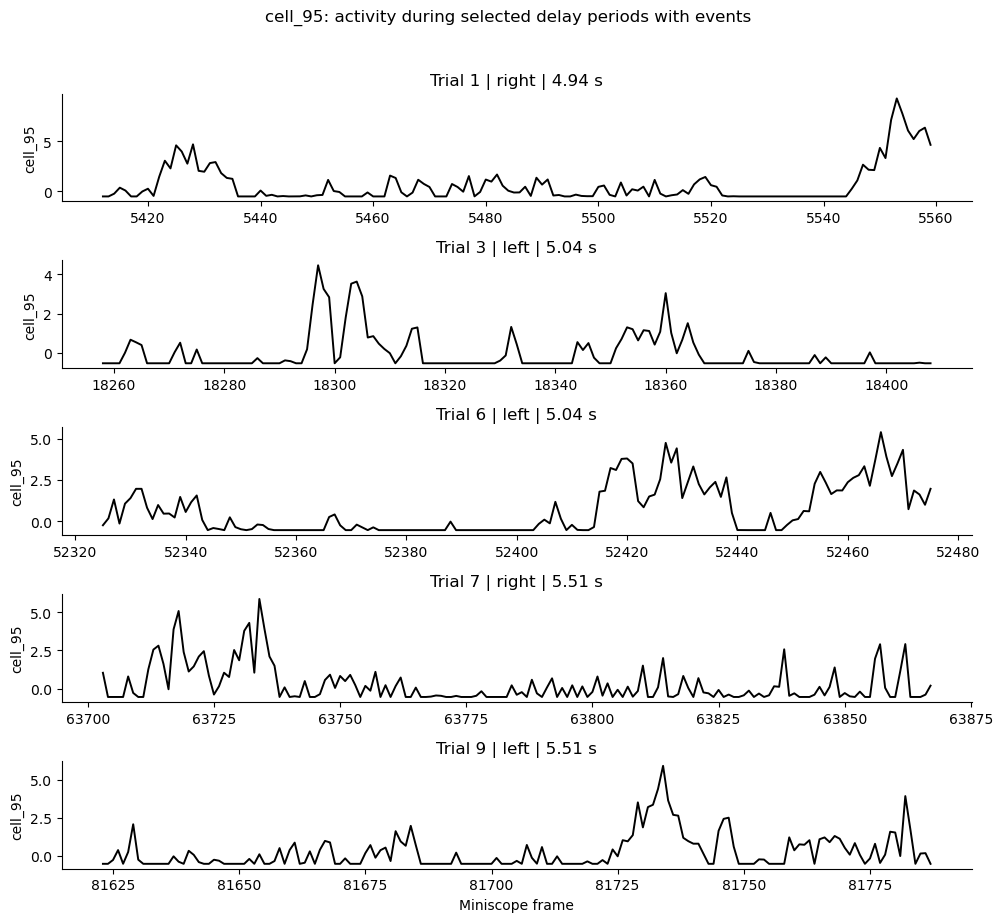

In [116]:
plot_input_cell_active_delays_stacked(
    cell="cell_95",
    calciumData=calciumData,
    delay_periods_df=delay_df_session1[delay_df_session1['delay_duration_s']<6],
    active_cells_summary_df=active_cells_summary_df,
)


In [125]:
corr_df_5_sec, binned_df_5_sec, meta_df_5_sec = correlate_input_cell_across_delays(
    cell="cell_95",
    calciumData=calciumData,
    delay_periods_df=delay_df_session1[delay_df_session1["delay_duration_s"] < 6],
    active_cells_summary_df=active_cells_summary_df,
    threshold=2.5,
    bin_width_frames=20,
    binarize_mode="any",
)

corr_df_5_sec

,T1,T3,T6,T7,T9
T1,1.000000,-0.166667,-0.166667,1.000000,-0.353553
T3,-0.166667,1.000000,-0.166667,-0.166667,0.471405
T6,-0.166667,-0.166667,1.000000,-0.166667,0.471405
T7,1.000000,-0.166667,-0.166667,1.000000,-0.353553
T9,-0.353553,0.471405,0.471405,-0.353553,1.000000


In [129]:
avg_corr_5_sec = corr_df.where(np.triu(np.ones(corr_df.shape, dtype=bool), k=1)).stack().mean()
avg_corr_5_sec

np.float64(-0.05299679747539443)

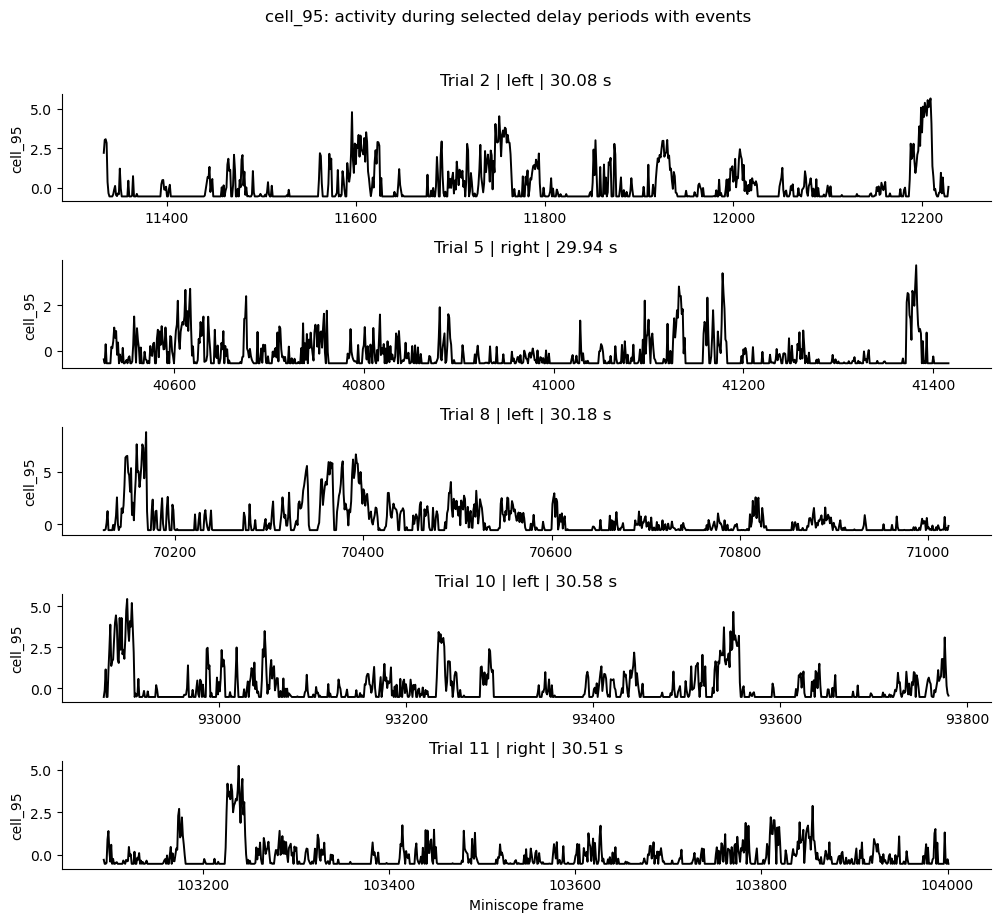

In [127]:
plot_input_cell_active_delays_stacked(
    cell="cell_95",
    calciumData=calciumData,
    delay_periods_df=delay_df_session1[delay_df_session1['delay_duration_s']>6],
    active_cells_summary_df=active_cells_summary_df,
)

In [130]:
corr_df_30_sec, binned_df_30_sec, meta_df_30_sec = correlate_input_cell_across_delays(
    cell="cell_95",
    calciumData=calciumData,
    delay_periods_df=delay_df_session1[delay_df_session1["delay_duration_s"] > 6],
    active_cells_summary_df=active_cells_summary_df,
    threshold=2.5,
    bin_width_frames=20,
    binarize_mode="any",
)

corr_df_30_sec

,T2,T5,T8,T10,T11
T2,1.000000,-0.016137,0.067508,0.054074,-0.193649
T5,-0.016137,1.000000,-0.239046,-0.125656,0.175000
T8,0.067508,-0.239046,1.000000,0.112641,-0.239046
T10,0.054074,-0.125656,0.112641,1.000000,-0.125656
T11,-0.193649,0.175000,-0.239046,-0.125656,1.000000


In [88]:
delay_df_session1

,trial_number,forced_side,delay_duration_s,delay_start_time,delay_end_time,delay_start_frame,delay_end_frame
0,1,right,4.939,257.067236,262.006716,5412.0,5559.0
1,2,left,30.081,456.053984,486.135164,11333.0,12228.0
2,3,left,5.040,688.783964,693.824014,18258.0,18408.0
3,4,right,30.078,914.421351,944.499123,24965.0,25860.0
4,5,right,29.944,1437.514767,1467.458657,40526.0,41416.0
5,6,left,5.040,1834.112381,1839.152712,52325.0,52475.0
6,7,right,5.512,2216.492839,2222.004723,63703.0,63867.0
7,8,left,30.179,2432.284365,2462.463806,70124.0,71022.0
8,9,left,5.511,2819.269724,2824.780927,81623.0,81787.0
9,10,left,30.579,3197.520441,3228.098971,92877.0,93780.0


In [33]:
calciumData

,Unnamed: 0,cell_1,cell_2,cell_4,cell_5,cell_8,cell_9,cell_10,cell_11,cell_12,...,cell_299,cell_300,cell_302,cell_303,cell_304,cell_305,cell_306,cell_307,cell_308,cell_309
0,0 days 00:00:00,-0.605606,7.869244,-0.499119,-0.595185,-0.342970,-0.549936,-0.572430,3.416981,-0.633596,...,-0.485753,-0.642576,0.610223,3.361113,1.005590,1.168537,0.691617,-0.434580,-0.647135,1.614950
1,0 days 00:00:00.050000,-0.605606,1.124798,0.222773,-0.595185,-0.153463,-0.549936,-0.572430,1.045004,-0.633596,...,-0.485753,2.017369,-0.697508,2.048084,-0.660291,-0.692100,11.914185,-0.499190,-0.647135,-0.664706
2,0 days 00:00:00.100000,-0.605606,2.954716,2.732061,0.330279,-0.342970,-0.549936,-0.572430,2.344835,-0.633596,...,-0.485753,1.782693,-0.593100,0.438445,12.444121,-0.692100,-0.274542,-0.383015,-0.647135,-0.436779
3,0 days 00:00:00.150000,-0.605606,1.204970,1.029710,-0.547890,-0.342970,-0.549936,-0.572430,-0.423562,1.135043,...,-0.485753,-0.642576,0.288491,-0.248011,1.304544,-0.692100,-0.632893,-0.591934,-0.647135,0.681317
4,0 days 00:00:00.200000,-0.605606,-0.534428,-0.655705,-0.160419,-0.342970,-0.549936,-0.158138,0.088094,-0.633596,...,-0.485753,-0.642576,-0.697508,-0.654395,-0.679802,-0.692100,-0.632893,-0.043017,0.159067,-0.125261
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115229,0 days 01:36:01.450000,1.571383,-0.340058,0.455599,-0.595185,-0.091074,-0.549936,0.285368,-0.510275,1.347199,...,0.304031,-0.642576,0.980106,-0.654395,-0.026120,0.732135,-0.387334,-0.591934,-0.647135,-0.664706
115230,0 days 01:36:01.500000,0.339203,0.357402,0.508813,0.213098,0.041844,-0.549936,-0.572430,-0.534254,-0.633596,...,-0.485753,0.078786,0.950376,0.721136,0.187030,-0.623183,-0.632893,1.214719,-0.647135,0.145100
115231,0 days 01:36:01.550000,-0.605606,-0.534428,-0.655705,-0.595185,-0.342970,-0.549936,-0.035254,0.489156,1.387969,...,0.587985,-0.642576,0.442585,-0.654395,-0.679802,-0.610731,-0.632893,1.453986,-0.647135,-0.664706
115232,0 days 01:36:01.600000,-0.424812,0.123940,-0.655705,-0.529656,0.460344,0.522914,0.400651,-0.534254,-0.633596,...,-0.016655,-0.642576,0.593043,-0.654395,-0.679802,-0.537649,-0.081534,0.555559,-0.647135,1.742963
